In [1]:
import openseespywin as ops
import opsvis as opsv 
import numpy as np
import ipywidgets as widgets
import os
import matplotlib.pyplot as plt
import math
import opstool as opst
#import eurocodepy as ecpy
import time as tt 
# import openseespy.postprocessing.Get_Rendering as opsplt

In [2]:
import sys
sys.path.append('Data')
import functions.solver_function as SF
import importlib
importlib.reload(SF)
from functions.solver_function import *  

In [3]:
opst.add_ops_hints_file()

OPSTOOL :: opensees.pyi file has been created to 
C:\Users\micha\miniconda3\envs\blue_env\Lib\site-packages\openseespywin\opensees.pyi!

In [4]:
convert_tcl = 'no'
if(convert_tcl=="yes"):
    opst.pre.tcl2py(input_file='create.tcl',
                output_file='create',
                prefix="ops")

In [5]:
length_unit = "m"  # base unit
force_unit = "KN"  # base unit

UNIT = opst.pre.UnitSystem(length=length_unit, force=force_unit)

print("Length:", UNIT.mm, UNIT.mm2, UNIT.cm, UNIT.m,)
print("Force", UNIT.N, UNIT.kN, )
print("Stress", UNIT.MPa, UNIT.kPa, UNIT.Pa, )
print("Mass", UNIT.g, UNIT.kg, UNIT.ton)
print(UNIT)

Length: 0.001 1e-06 0.01 1
Force 0.001 1
Stress 1000.0 1.0 0.001
Mass 1e-06 0.001 1.0
<UnitSystem: length='m', force='kn', time='sec' (159447744559)>


In [6]:
# --- Python Code (Translated from TCL) ---

# Created by Zhaohui Yang (zhyang@ucsd.edu)
# Plastic pressure-dependent material
# Plane strain, single element, dynamic analysis (input motion: sinusoidal acceleration at base)
# SI units (m, s, KN, ton)
#
#        4-----3
#        |     |
#        |     |
#        |     |
#       1-------2 (nodes 1 and 2 fixed)
#        ^     ^
#        <--> input motion: sinusoidal acceleration at base

ops.wipe()
#print("Model wiped and ready to build.")

# --- User-defined variables ---
accMul = 2.0  # acceleration multiplier
massDen = 2.00  # solid mass density
fluidDen = 1.0  # fluid mass density
massProportionalDamping = 0.0
stiffnessProportionalDamping = 0.001
fangle = 31.40  # friction angle
ptangle = 26.50  # phase transformation angle
E = 90000.0  # shear modulus
poisson = 0.40
G = E / (2.0 * (1.0 + poisson))
B = E / (3.0 * (1.0 - 2.0 * poisson))
press = 0.0  # isotropic consolidation pressure on quad element(s)
deltaT = 0.010  # time step for analysis
numSteps = 2000  # Number of analysis steps
gamma = 0.600  # Newmark integration parameter
period = 1.0  # Period of applied sinusoidal load
pi = 3.1415926535
inclination = 4.0
unitWeightX = (massDen - fluidDen) * 9.81 * math.sin(inclination / 180.0 * pi)
unitWeightY = -(massDen - fluidDen) * 9.81 * math.cos(inclination / 180.0 * pi)

# #############################################################

# --- Create the ModelBuilder ---
ops.model('basic', '-ndm', 2, '-ndf', 2)

# --- Define material and properties ---
# nDMaterial PressureDependMultiYield
ops.nDMaterial('PressureDependMultiYield', 2, 2, massDen, G, B, fangle, 0.1, 80, 0.5,
               ptangle, 0.17, 0.4, 10, 10, 0.015, 1.0)
# nDMaterial FluidSolidPorous
ops.nDMaterial('FluidSolidPorous', 1, 2, 2, 2.2e6)

# --- Define the nodes ---
ops.node(1, 0.0, 0.0)
ops.node(2, 1.0, 0.0)
ops.node(3, 1.0, 1.0)
ops.node(4, 0.0, 1.0)

# --- Define the element ---
# element quad eleTag n1 n2 n3 n4 thick 'PlaneStrain' maTag press density gravity
ops.element('quad', 1, 1, 2, 3, 4, 1.0, 'PlaneStrain', 1, press, 0.0, unitWeightX, unitWeightY)

# --- Update material stages ---
ops.updateMaterialStage('-material', 1, '-stage', 0)
ops.updateMaterialStage('-material', 2, '-stage', 0)

# --- Fix the base ---
ops.fix(1, 1, 1)
ops.fix(2, 1, 1)

# --- Tie nodes 3 and 4 ---
ops.equalDOF(3, 4, 1, 2)

# #############################################################
# GRAVITY APPLICATION (elastic behavior)

# --- create the SOE, ConstraintHandler, Integrator, Algorithm and Numberer ---
ops.system('ProfileSPD')
ops.test('NormDispIncr', 1.0e-12, 25, 0)
ops.constraints('Transformation')
ops.integrator('LoadControl', 1, 1, 1, 1)
ops.algorithm('Newton')
ops.numberer('RCM')

# --- create the Analysis ---
ops.analysis('Static')

# --- analyze ---
ops.analyze(2)


newBulk = G * 2 / 3
# --- switch the material to plastic ---
# switch material in Python

ops.parameter(1001, 'element', 1, "bulkModulus", '2')

ops.updateMaterialStage("-material", 1, "-stage", 1)
ops.updateMaterialStage("-material", 2, "-stage", 1)
ops.updateParameter(1001, newBulk) 


# --- analyze ---
ops.analyze(1)


0

In [7]:
ops.printModel()

Current Domain Information
	Current Time: 3
	Committed Time: 3
NODE DATA: NumNodes: 4

numComponents: 4

 Node: 1
	Coordinates  : 0 0 
	Disps: 0 0 
	 unbalanced Load: 0 0 
	ID : -1 -1 


 Node: 2
	Coordinates  : 1 0 
	Disps: 0 0 
	 unbalanced Load: 0 0 
	ID : -1 -1 


 Node: 3
	Coordinates  : 1 1 
	Disps: 1.06448e-05 -2.53714e-05 
	 unbalanced Load: 0 0 
	ID : 0 1 


 Node: 4
	Coordinates  : 0 1 
	Disps: 1.06448e-05 -2.53714e-05 
	 unbalanced Load: 0 0 
	ID : 0 1 

ELEMENT DATA: NumEle: 1

numComponents: 1

FourNodeQuad, element id:  1
	Connected external nodes:  1 2 3 4 
	thickness:  1
	surface pressure:  0
	mass density:  0
	body forces:  0.684311 -9.7861
FluidSolidPorousMaterial
	Stress (xx yy xy)
		Gauss point 1: -3.26203 -4.89305 0.342156 
		Gauss point 2: -3.26203 -4.89305 0.342156 
		Gauss point 3: -3.26203 -4.89305 0.342156 
		Gauss point 4: -3.26203 -4.89305 0.342156 

SP_Constraints: numConstraints: 4

numComponents: 4
SP_Constraint: 0	 Node: 1 DOF: 1 ref value: 0 current val

In [8]:
opst.vis.plotly.plot_model(show_node_numbering=True, show_ele_numbering=False, show_nodal_loads = True)

In [9]:
# #############################################################
# NOW APPLY LOADING SEQUENCE AND ANALYZE (plastic)

# --- rezero time ---
ops.setTime(0.0)
ops.wipeAnalysis()

# --- pattern for dynamic loading ---
ops.timeSeries('Sine', 1, 0.0, 10.0, period, "-factor", accMul)
ops.pattern("UniformExcitation", 1, 1, "-accel",1)

# --- create the Analysis ---
ops.constraints('Transformation')
ops.test('NormDispIncr', 1.0e-6, 25, 0)
ops.algorithm('Newton')
ops.numberer('RCM')
ops.system('ProfileSPD')
ops.rayleigh(massProportionalDamping, 0.0, stiffnessProportionalDamping, 0.0)
ops.integrator('Newmark', gamma, (gamma + 0.5)**2 / 4.0)
ops.analysis('VariableTransient')

# --- Recorders ---
# Node recorders
ops.recorder('Node', '-file', 'bdisp.out', '-time', '-node', 1, 2, 3, 4, '-dof', 1, 2, '-dT', 0.01, 'disp')
ops.recorder('Node', '-file', 'bacce.out', '-time', '-node', 1, 2, 3, 4, '-dof', 1, 2, '-dT', 0.01, 'accel')

# Element recorders
ops.recorder('Element', '-ele', 1, '-time', '-file', 'bstress1.out', '-dT', 0.01, 'material', 1, 'stress')
ops.recorder('Element', '-ele', 1, '-time', '-file', 'bstrain1.out', '-dT', 0.01, 'material', 1, 'strain')
ops.recorder('Element', '-ele', 1, '-time', '-file', 'bstress3.out', '-dT', 0.01, 'material', 3, 'stress')
ops.recorder('Element', '-ele', 1, '-time', '-file', 'bstrain3.out', '-dT', 0.01, 'material', 3, 'strain')
ops.recorder('Element', '-ele', 1, '-time', '-file', 'bpress1.out', '-dT', 0.01, 'material', 1, 'pressure')
ops.recorder('Element', '-ele', 1, '-time', '-file', 'bpress3.out', '-dT', 0.01, 'material', 3, 'pressure')

# --- analyze ---
startT = tt.time()
ops.analyze(numSteps, deltaT, deltaT / 100, deltaT, 10)
endT = tt.time()
print(f"Execution time: {endT - startT} seconds.")

# --- Final cleanup ---
ops.wipe()

Execution time: 0.21099424362182617 seconds.


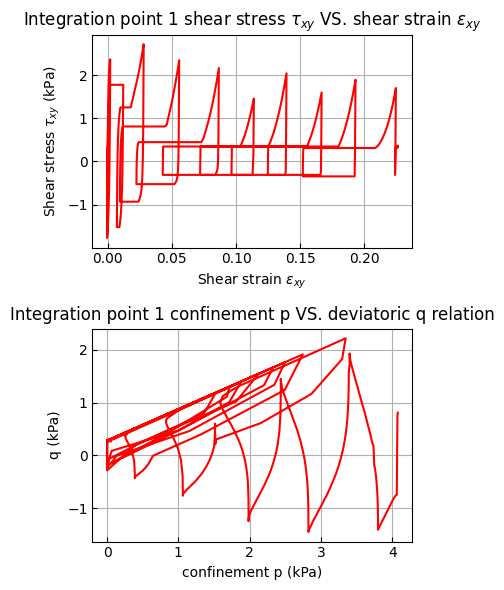

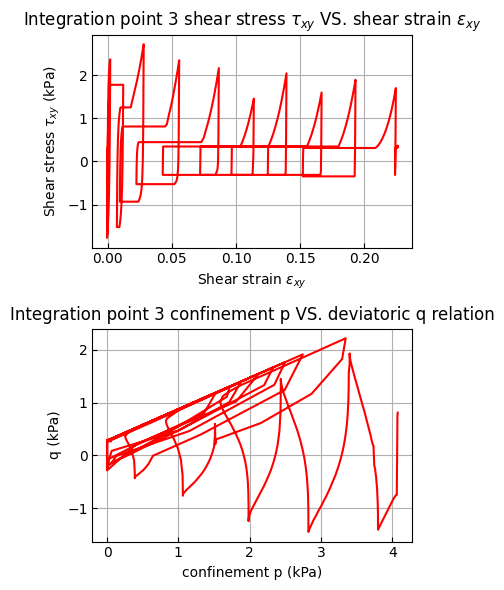

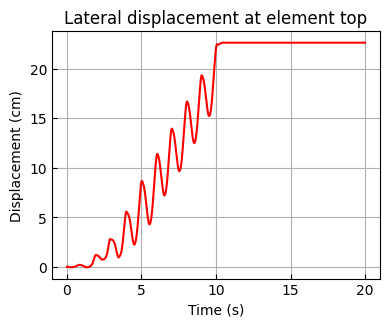

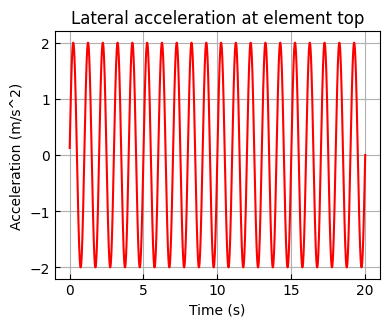

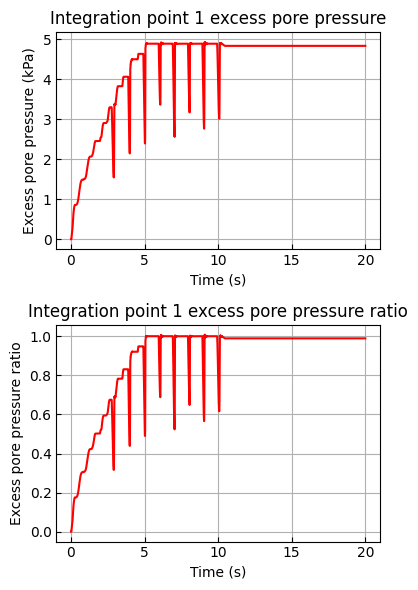

In [10]:
# --- 1. Load the data from files ---
a1 = np.loadtxt('bacce.out')
d1 = np.loadtxt('bdisp.out')
s1 = np.loadtxt('bstress1.out')
e1 = np.loadtxt('bstrain1.out')
s5 = np.loadtxt('bstress3.out')
e5 = np.loadtxt('bstrain3.out')
p1 = np.loadtxt('bpress1.out')
p3 = np.loadtxt('bpress3.out')

# Define global variables
fs = [0., 0.2, 4, 6]  # [left, bottom, width, height] for paperposition
accMul = 2

# --- 2. Helper function for p-q calculations and plotting ---
def plot_stress_strain_and_pq(stress_data, strain_data, figure_num, title_suffix, filename):
    """
    Plots the shear stress vs. shear strain and confinement vs. deviatoric stress.

    Parameters:
    - stress_data (np.ndarray): The stress data matrix.
    - strain_data (np.ndarray): The strain data matrix.
    - figure_num (int): The figure number for the plot.
    - title_suffix (str): A string for the plot titles.
    - filename (str): The base name for saving the figure.
    """
    # Calculate p (mean normal stress)
    po = (stress_data[:, 1] + stress_data[:, 2] ) / 2.0

    # Calculate q (deviatoric stress)
    term1 = (stress_data[:, 1] - stress_data[:, 2])**2
    term2 = (stress_data[:, 2] - stress_data[:, 1])**2
    
    term4 = 6.0 * stress_data[:, 3]**2
    qo = np.sqrt(term1 + term2 + term4) / 3.0
    
    # Apply the sign of s_xy (stress_data[:, 4]) to qo
    qo = np.sign(stress_data[:, 3]) * qo

    # Create the figure and subplots
    plt.figure(figure_num, figsize=(fs[2], fs[3]))
    plt.clf()
    
    # Subplot 1: Shear stress vs. shear strain
    plt.subplot(2, 1, 1)
    plt.plot(strain_data[:, 3], stress_data[:, 3], 'r')
    plt.title(f'{title_suffix} shear stress $\\tau_{{xy}}$ VS. shear strain $\\epsilon_{{xy}}$')
    plt.xlabel('Shear strain $\\epsilon_{{xy}}$')
    plt.ylabel('Shear stress $\\tau_{{xy}}$ (kPa)')
    plt.grid(True)

    # Subplot 2: Confinement vs. deviatoric stress
    plt.subplot(2, 1, 2)
    plt.plot(-po, qo, 'r')
    plt.title(f'{title_suffix} confinement p VS. deviatoric q relation')
    plt.xlabel('confinement p (kPa)')
    plt.ylabel('q (kPa)')
    plt.grid(True)
    
    plt.tight_layout()
    plt.savefig(f'{filename}.jpg', dpi=300)

# --- 3. Plotting the data for different integration points ---
plot_stress_strain_and_pq(s1, e1, 1, 'Integration point 1', 'SS_PQ1')
plot_stress_strain_and_pq(s5, e5, 4, 'Integration point 3', 'SS_PQ5')

# --- 4. Plotting displacement data ---
plt.figure(2, figsize=(fs[2], fs[3]))
plt.clf()
plt.subplot(2, 1, 1)
plt.plot(d1[:, 0], d1[:, 5] * 100, 'r')
plt.title('Lateral displacement at element top')
plt.xlabel('Time (s)')
plt.ylabel('Displacement (cm)')
plt.grid(True)
plt.tight_layout()
plt.savefig('D.jpg', dpi=300)

# --- 5. Plotting acceleration data ---
plt.figure(3, figsize=(fs[2], fs[3]))
plt.clf()

# Interpolate the sine wave. The time range is now 0:0.01:20 and the sine wave is
# calculated for 0:pi/50:40*pi. The `interp1` function in MATLAB handles this implicitly.
# In NumPy, we create the source and destination arrays and then use np.interp.
t_sine_source = np.arange(0, 40.01, 0.01) # a slightly different approach to match interp1
s_wave = accMul * np.sin(np.arange(0, 40*np.pi + 1e-9, np.pi/50))

s_interpolated = np.interp(a1[:, 0], t_sine_source[:len(s_wave)], s_wave)

# Plotting the acceleration
plt.subplot(2, 1, 1)
plt.plot(a1[:, 0], s_interpolated + a1[:, 4], 'r')
plt.title('Lateral acceleration at element top')
plt.xlabel('Time (s)')
plt.ylabel('Acceleration (m/s^2)')
plt.grid(True)
plt.tight_layout()
plt.savefig('A.jpg', dpi=300)


# --- 6. Plotting pore pressure data ---
plt.figure(5, figsize=(fs[2], fs[3]))
plt.clf()

# Subplot 1: Excess pore pressure
plt.subplot(2, 1, 1)
plt.plot(p1[:, 0], -p1[:, 1], 'r')
plt.title('Integration point 1 excess pore pressure')
plt.xlabel('Time (s)')
plt.ylabel('Excess pore pressure (kPa)')
plt.grid(True)

# Subplot 2: Excess pore pressure ratio
plt.subplot(2, 1, 2)
plt.plot(p1[:, 0], p1[:, 2], 'r')
plt.title('Integration point 1 excess pore pressure ratio')
plt.xlabel('Time (s)')
plt.ylabel('Excess pore pressure ratio')
plt.grid(True)

plt.tight_layout()
plt.savefig('EPWP.jpg', dpi=300)

plt.show()